# Base model

In [1]:
import common_functions
import sklearn
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf

I0000 00:00:1778704256.161110  165998 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778704256.194139  165998 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778704256.957661  165998 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
os.environ["CUDA_CACHE_MAXSIZE"] = "4294967296"

## Generating dataset

In [4]:
IMAGES_PATH = "data/raw_images/"
MASKS_PATH = "data/manual_masks/"
DATASET_PATH = "generated_data/base_dataset/"

In [5]:
common_functions.generate_dataset_by_grid_patching(IMAGES_PATH, MASKS_PATH, DATASET_PATH, size=(256, 256))

Output path generated_data/base_dataset/ already exists.


In [6]:
X, y = common_functions.load_images_as_dataset(DATASET_PATH)
X_train, X_val, y_train, y_val = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

W0000 00:00:1778704260.959553  165998 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [9]:
model, history = common_functions.train_unet_model(
    X_train, 
    y_train, 
    X_val, 
    y_val, 
    epochs=20, 
    batch_size=16, 
    validation_batch_size=16
)

Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 59s 114ms/step - accuracy: 0.8008 - loss: 0.4020 - val_accuracy: 0.8929 - val_loss: 0.2856
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 0.9007 - loss: 0.2423 - val_accuracy: 0.9124 - val_loss: 0.2204
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.9201 - loss: 0.2023 - val_accuracy: 0.9244 - val_loss: 0.1888
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - accuracy: 0.9296 - loss: 0.1801 - val_accuracy: 0.9358 - val_loss: 0.1668
Epoch 5/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 0.9345 - loss: 0.1683 - val_accuracy: 0.9375 - val_loss: 0.1516
Epoch 6/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 0.9393 - loss: 0.1552 - val_accuracy: 0.9419 - val_loss: 0.1484
Epoch 7/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - accuracy: 0.9421 - loss: 0.1480 - val_accuracy: 0.9418 - val_loss: 0.1483
Epoch 8/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - accuracy: 0.9432 - loss: 0.1438 -

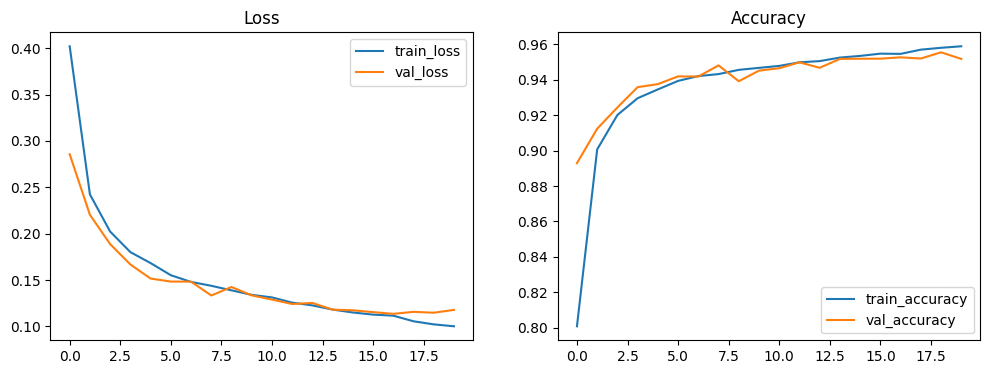

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()

In [13]:
model.save("models/trained/baseline_unet.keras")

In [14]:
model.load_weights("models/trained/baseline_unet.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


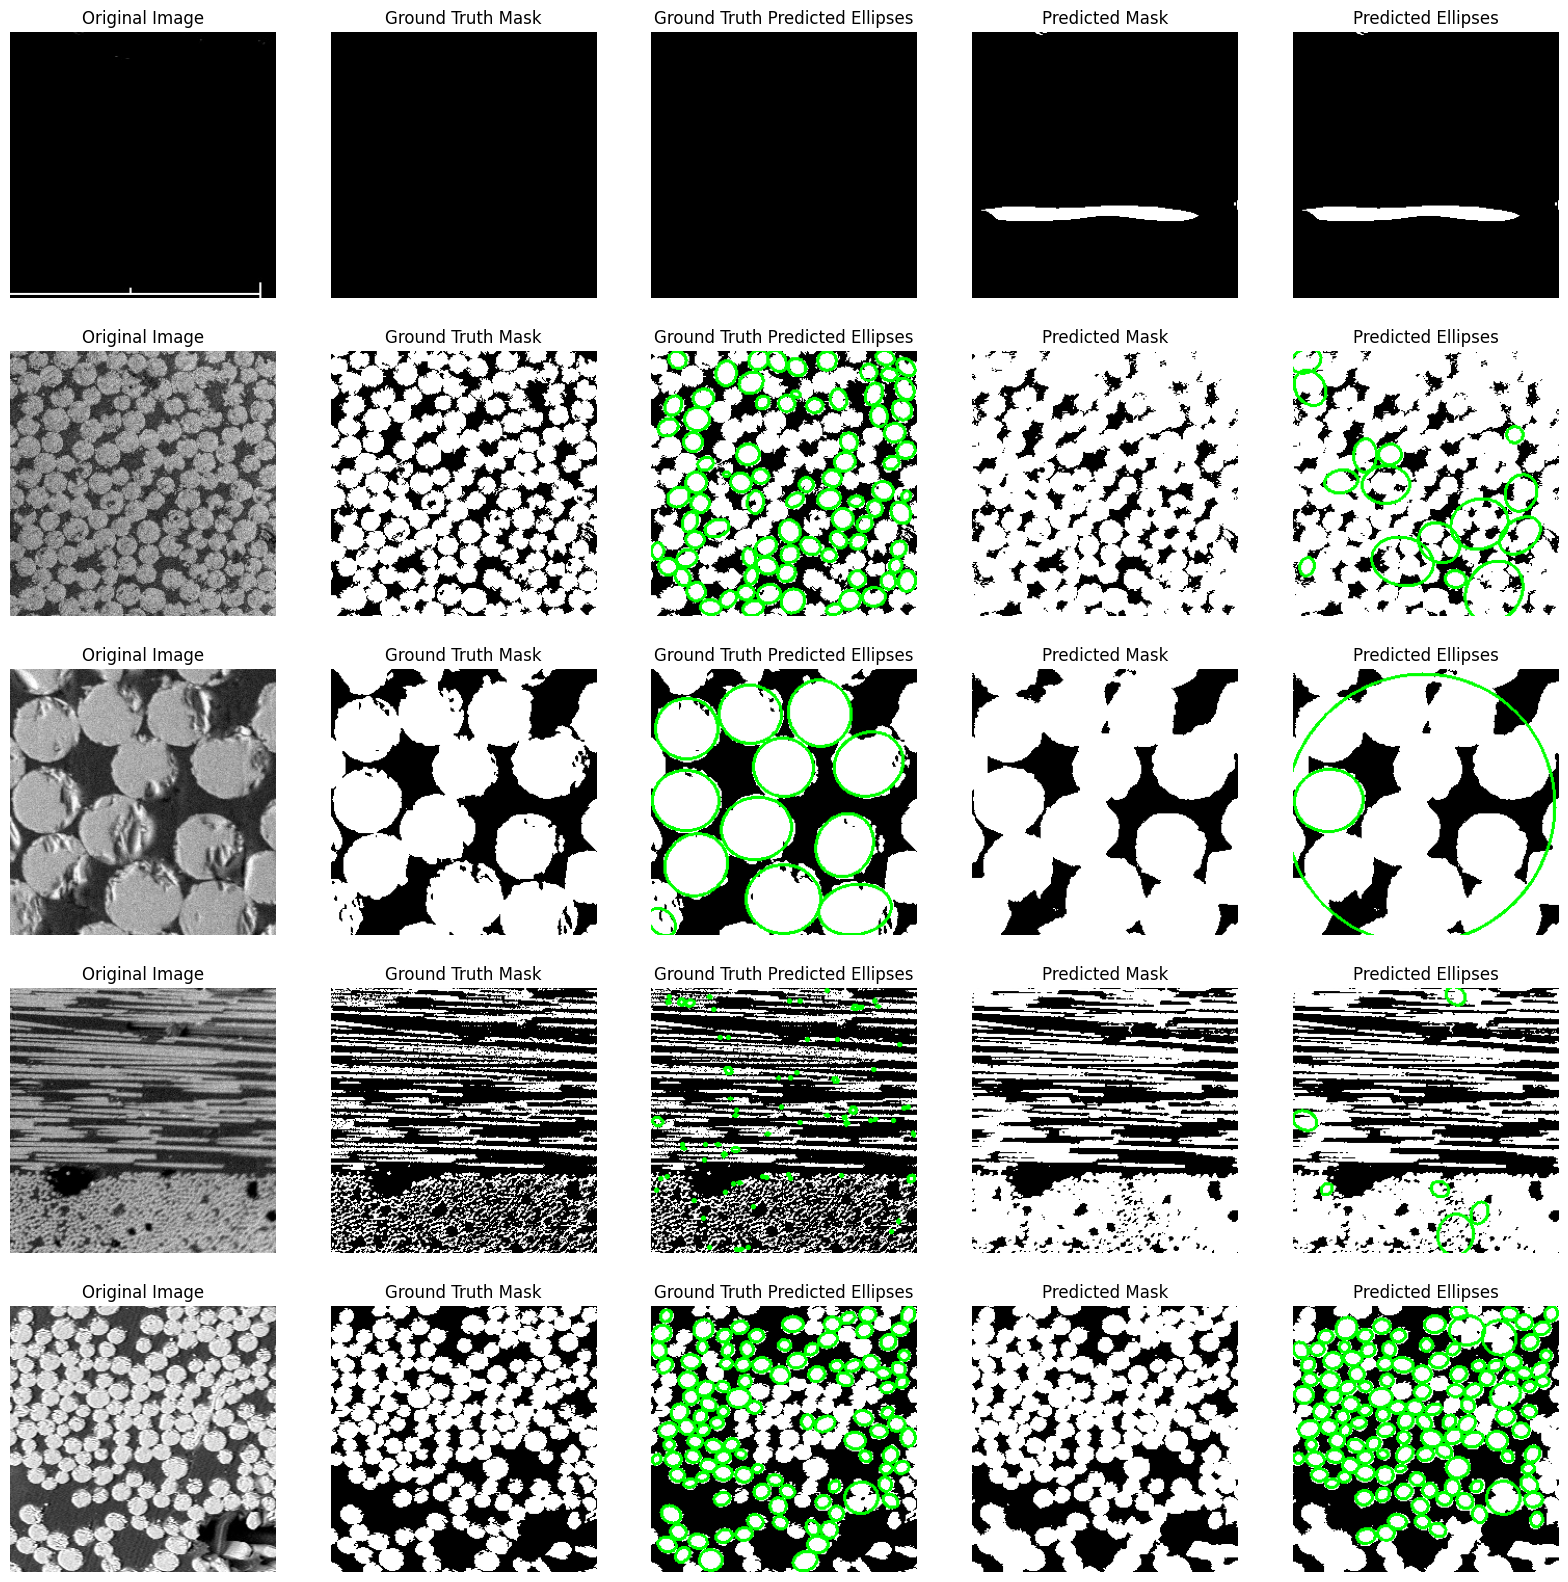

In [25]:
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
for i in range(5):
    idx = i * 10
    img = X_val[idx]
    true_mask = y_val[idx]
    pred_mask = (model.predict(img[np.newaxis, ...])[0] > 0.5).astype(np.uint8) * 255

    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(true_mask.squeeze(), cmap='gray')
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(common_functions.draw_ellipses_on_image(true_mask.squeeze(), common_functions.find_ellipses_in_mask(true_mask.squeeze())))
    axes[i, 2].set_title("Ground Truth Predicted Ellipses")
    axes[i, 2].axis('off')

    axes[i, 3].imshow(pred_mask.squeeze(), cmap='gray')
    axes[i, 3].set_title("Predicted Mask")
    axes[i, 3].axis('off')

    axes[i, 4].imshow(common_functions.draw_ellipses_on_image(pred_mask.squeeze(), common_functions.find_ellipses_in_mask(pred_mask.squeeze())))
    axes[i, 4].set_title("Predicted Ellipses")
    axes[i, 4].axis('off')